# Inspect a PET image–report pair

## Goal
Use the training pipeline's `PetReportDataset` to inspect one paired scan and report.
The two panels are **independent coronal and sagittal model inputs**, not a montage
fed to the model. No model weights or GPU are needed.

The notebook is saved without patient-data outputs. Running the display cell renders
the selected pair locally; clear outputs before sharing the notebook.

## Setup
Select the repository's `.local/pet-cuda-venv/bin/python` as your notebook kernel.
It needs `nbformat`, `nbclient`, `ipykernel`, and `matplotlib` in addition to the
training dependencies. These packages are installed in the current PET environment.
If recreating that environment, run from the repository root:

```bash
uv pip install --python .local/pet-cuda-venv/bin/python nbformat nbclient ipykernel matplotlib
```

Open this notebook from `tutorials/` or the repository root. Set `REPO_ROOT` explicitly
in the following cell if launching from elsewhere.

In [14]:
from pathlib import Path
import sys
import os

REPO_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "src/open_clip_train/pet_data.py").is_file()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Set REPO_ROOT to the open_clip checkout before continuing.")
sys.path.insert(0, str(REPO_ROOT / "src"))

os.environ.setdefault("HF_HOME", str(REPO_ROOT / ".local/pet/hf-cache"))

import html
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import HTML, display

from open_clip import get_tokenizer
from open_clip_train.pet_data import PetReportDataset, SUV_MEAN, SUV_STD

### Choose a partition and sample
`val` gives deterministic centered padding without training augmentation. Choose
`train` to inspect the same random placement and post-normalization intensity scaling
used in training. `SEED` makes the selected training example reproducible.

`cache="none"` loads only requested PET views from the original binaries. It avoids
caching the whole partition or creating converted files. Pair metadata is held in RAM.

`MODEL_NAME` now selects pretrained Bio_ClinicalBERT WordPiece tokenization.
The 2,560-token report context is encoded in native 512-token BERT windows during
training; this notebook only tokenizes reports and does not load model weights.
Use `PET-ResNet34-Local` to inspect the previous scratch CLIP tokenizer.

In [18]:
DATA_ROOT = Path("/mnt/snotra1/ida/datasets/lymphoma_mskcc_deid")
PARTITION = "val"  # "train", "val", or "test"
SPLIT_COLUMN = "split0"
SAMPLE_INDEX = 88
SEED = 0
MODEL_NAME = "PET-ResNet34-BioClinicalBERT-Local"
CONTEXT_LENGTH = 2560

if not DATA_ROOT.is_dir():
    raise FileNotFoundError(DATA_ROOT)

tokenizer = get_tokenizer(MODEL_NAME, context_length=CONTEXT_LENGTH)
dataset = PetReportDataset(
    root=DATA_ROOT,
    tokenizer=tokenizer,
    partition=PARTITION,
    split_column=SPLIT_COLUMN,
    image_size=310,
    intensity_max=30.0,
    cache="none",
    report_sections="findings_impression",
)
print(f"{PARTITION}: {len(dataset):,} paired scans; images loaded on demand")

Model configuration not found, returning default SimpleTokenizer.


val: 2,466 paired scans; images loaded on demand


## Steps
### Display a pair
The plot uses the actual normalized tensors returned by `dataset[index]`:
`(clip(SUV, 0, 30) - 2.13) / 3.39`, with optional training augmentation afterward.
Both panels share one color scale. Darker pixels indicate higher normalized uptake;
the color bar is **not raw SUV**, especially when training intensity scaling is on.
Array orientation is preserved from the loader; no anatomical direction labels are
inferred from these binary projections.

Below the images, compare two independently scrollable panels:
- **Original report:** `record["full_report"]`, before section extraction.
- **Filtered training text:** `record["report"]`, the Findings and Impression
  sections (Summary excluded) actually passed to the tokenizer.

The filtered text is read directly from `PetReportDataset`, so this preview uses
the same extraction rules as training. Token counts include the two special tokens
and are measured before padding/truncation. The dataset sample's `text` field contains
token IDs; the assertion below checks they match the filtered text.

In [19]:
def show_pair(dataset, index, seed=0):
    if not 0 <= index < len(dataset):
        raise IndexError(f"index must be between 0 and {len(dataset) - 1}")

    # Reproduce training augmentation without changing the caller's NumPy RNG state.
    rng_state = np.random.get_state()
    try:
        np.random.seed(seed)
        sample = dataset[index]
    finally:
        np.random.set_state(rng_state)
    record = dataset.records[index]
    images = sample["image"].detach().cpu()

    assert images.shape == (2, 1, 310, 310)
    assert images.dtype == torch.float32 and torch.isfinite(images).all()
    assert sample["text"].shape == (CONTEXT_LENGTH,)
    expected_tokens = tokenizer([record["report"]])[0]
    assert torch.equal(sample["text"], expected_tokens), "Report/token pairing mismatch"

    low = min(float(images.min()), -SUV_MEAN / SUV_STD)
    high = max(float(images.max()), (dataset.intensity_max - SUV_MEAN) / SUV_STD)
    fig, axes = plt.subplots(1, 2, figsize=(9, 6), constrained_layout=True)
    for view, (ax, name) in enumerate(zip(axes, ("Coronal — view 0", "Sagittal — view 1"))):
        plot = ax.imshow(images[view, 0].numpy(), cmap="gray_r", vmin=low, vmax=high,
                         origin="upper", interpolation="nearest")
        ax.set_title(name)
        ax.set_axis_off()
    fig.colorbar(plot, ax=axes, shrink=0.75, label="Normalized model-input intensity")
    fig.suptitle(f"{PARTITION} sample {index} | pair {record['pair_id'][:12]}")
    plt.show()
    plt.close(fig)

    original = record["full_report"]
    filtered = record["report"]
    original_tokens = len(tokenizer.encode(original)) + 2
    filtered_tokens = len(tokenizer.encode(filtered)) + 2
    sections = ", ".join(record["report_sections"])

    def report_panel(title, text, tokens):
        return (
            '<section style="flex:1 1 360px;min-width:0">'
            f'<h3>{html.escape(title)}</h3><p>{tokens:,} tokens before padding/truncation</p>'
            '<div style="max-height:500px;overflow:auto;border:1px solid #aaa;padding:12px">'
            '<pre style="white-space:pre-wrap;overflow-wrap:anywhere;font:inherit">'
            f'{html.escape(text)}</pre></div></section>'
        )

    display(HTML(
        f'<p><strong>Sections used:</strong> {html.escape(sections)}; '
        f'<strong>context:</strong> {CONTEXT_LENGTH:,} tokens.</p>'
        '<div style="display:flex;flex-wrap:wrap;gap:20px;align-items:flex-start">'
        + report_panel("Original report", original, original_tokens)
        + report_panel("Filtered training text — Findings / Impression", filtered, filtered_tokens)
        + '</div>'
    ))
    if filtered_tokens > CONTEXT_LENGTH:
        print("This filtered report exceeds the context and will be truncated by the tokenizer.")
    return sample


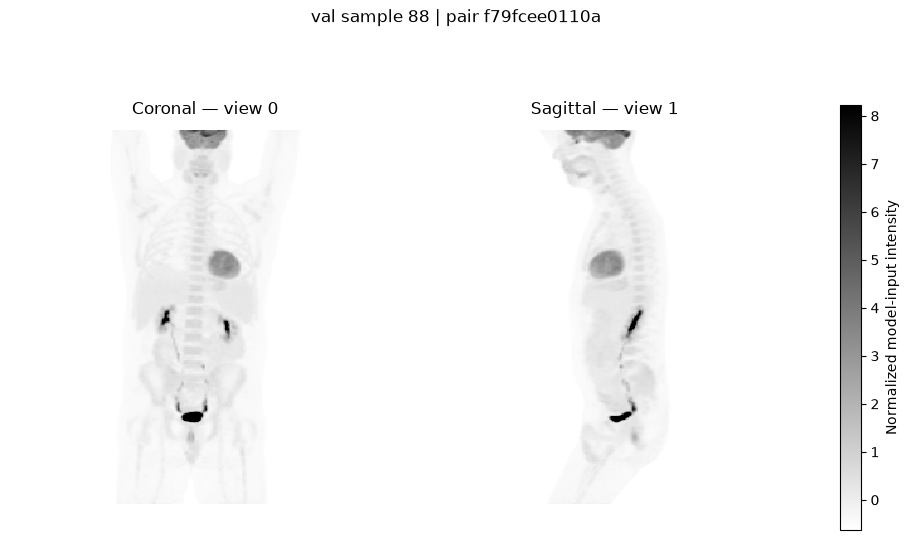

In [20]:
sample = show_pair(dataset, SAMPLE_INDEX, seed=SEED)

### Pixel-intensity histograms
Compare the coronal and sagittal pixel distributions for the **same sample shown
above**, using its actual normalized model-input tensors. All pixels are included,
including padded background. These are not raw PET intensities or calibrated SUV.
Training augmentation, when enabled, is already reflected in these values.

Both views use the same bin edges and axes. Pixel counts use a logarithmic scale
so that the large background peak does not hide less frequent intensities. Change
`HISTOGRAM_BINS` to adjust detail. After selecting another sample, rerun the display
cell and this cell.

In [ ]:
HISTOGRAM_BINS = 80
pixels_by_view = sample["image"].detach().cpu().numpy()[:, 0]
assert np.isfinite(pixels_by_view).all()
hist_low = float(pixels_by_view.min())
hist_high = float(pixels_by_view.max())
if hist_low == hist_high:
    hist_low, hist_high = hist_low - 0.5, hist_high + 0.5
bin_edges = np.linspace(hist_low, hist_high, HISTOGRAM_BINS + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, pixels, name, color in zip(
    axes, pixels_by_view, ("Coronal — view 0", "Sagittal — view 1"),
    ("tab:blue", "tab:orange"),
):
    counts, _ = np.histogram(pixels.ravel(), bins=bin_edges)
    assert int(counts.sum()) == pixels.size, "Histogram must include every pixel"
    ax.stairs(counts, bin_edges, fill=True, color=color, alpha=0.75)
    ax.set_yscale("log")
    ax.set_ylim(bottom=0.8)
    ax.set_title(f"{name} | {pixels.size:,} pixels")
    ax.set_xlabel("Normalized model-input intensity")
    ax.grid(axis="y", alpha=0.2)
axes[0].set_ylabel("Pixel count (log scale)")
fig.suptitle("Pixel distributions of the displayed PET pair (including padding)")
plt.show()
plt.close(fig)

## Checks
The display helper checks image shape, finite pixel values, token length, and exact
agreement between the dataset's token IDs and the report at the same record index.
The dataset itself applies the training pipeline's pair filtering, partition
selection, binary-size checks, and preprocessing. One displayed example does not
establish clinical correctness of every pairing.

In [ ]:
print("Image tensor:", tuple(sample["image"].shape), sample["image"].dtype)
print("Report token tensor:", tuple(sample["text"].shape), sample["text"].dtype)
print("Training augmentation:", dataset.training)
print("RAM image cache allocated:", dataset.image_cache is not None)
print("Pair checks passed.")

## Next steps
Change `SAMPLE_INDEX` and rerun the display cell to browse another pair. To change
partition, rerun the dataset-construction cell first. With `PARTITION="train"`,
change `SEED` to inspect alternate augmentation of the same pair.

This notebook does not train a model, export PET images, or implement visual
grounding. The plot shows the two independently encoded views before concatenation
of their pooled model features.